In [163]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="minimax-m3:cloud",
    temperature=0
)

In [164]:
from typing import TypedDict
from pydantic import BaseModel,Field
from langgraph.graph import END,StateGraph


#### 1.use case: Routing - Task classifier for summarization and translation

In [165]:
class RouteState(TypedDict):
    user_input:str
    task_type:str
    output:str

In [166]:
class Router(BaseModel):
    role:str=Field(...,description="Decide whether the user wants to summarize a passage ouput 'summarize' or translate text into french output 'translate' ")
llm_router=llm.bind_tools([Router])

In [167]:
response=llm_router.invoke("summarize this i love the sun its so warm")

In [168]:
def router_node(state:RouteState)->RouteState:
    routing_prompt=f"""
    You are an AI  task clasifier.
    
    Decide whether a user wants to :
    - "summarize" a passage
    - "translate" a text into french
    
    Respond with just one word: "summarize" or "translate"
    
    User input:"{state['user_input']}"
    """
    response=llm_router.invoke(routing_prompt)
    print(response)
    
    return {**state,"task_type":response.content.strip().lower()}

ouput of response.tool_calls:
[
    {
        "name": "route_task",
        "args": {
            "role": "summarize"
        },
        "id": "call_123"
    }
]

In [169]:
def router(state: RouteState)->str:
    return state['task_type']

In [170]:
def summarize_node(state: RouteState) -> RouteState:
    prompt = f"Please summarize the following passage:\n\n{state['user_input']}"
    response = llm.invoke(prompt)
    
    return {**state, "task_type": "summarize", "output": response.content}

In [171]:
def translate_node(state: RouteState) -> RouteState:
    prompt = f"Translate the following text to French:\n\n{state['user_input']}"
    response = llm.invoke(prompt)

    return {**state, "task_type": "translate", "output": response.content}

In [172]:
workflow=StateGraph(RouteState)

In [173]:
workflow.add_node("router",router_node)
workflow.add_node("summarizer",summarize_node)
workflow.add_node("translator",translate_node)
workflow.set_entry_point("router")
workflow.add_conditional_edges(
    "router",
    router,
    {"summarize":"summarizer",
     "translate":"translator"}
    )
workflow.set_finish_point("summarizer")
workflow.set_finish_point("translator")

In [174]:
app=workflow.compile()

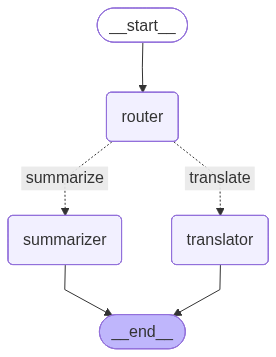

In [175]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [176]:
input_text = {
        "user_input": "my favourite subject is science"
    }

result = app.invoke(input_text)

content='translate' additional_kwargs={} response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-24T13:10:30.886590796Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1244363332, 'load_duration': None, 'prompt_eval_count': None, 'prompt_eval_duration': None, 'eval_count': 14, 'eval_duration': None, 'logprobs': None, 'model_name': 'minimax-m3', 'model_provider': 'ollama'} id='lc_run--019ef9c0-e6e3-7802-806e-1957914572c2-0' tool_calls=[] invalid_tool_calls=[]


In [177]:
print(result[ 'output'])
print(result['task_type'])

**French translation:**

"Mon sujet préféré est la science."

(Alternative, commonly used for school subjects: **"Ma matière préférée est la science."**)
translate


In [178]:
input_text = {
        "user_input": "Can you summarize this sentence: I love programming so much it is the best thing ever. All I want to do is programming?"
    }

result = app.invoke(input_text)

content='summarize' additional_kwargs={} response_metadata={'model': 'minimax-m3', 'created_at': '2026-06-24T13:10:38.381279448Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1032068424, 'load_duration': None, 'prompt_eval_count': None, 'prompt_eval_duration': None, 'eval_count': 27, 'eval_duration': None, 'logprobs': None, 'model_name': 'minimax-m3', 'model_provider': 'ollama'} id='lc_run--019ef9c1-01a5-7420-9c49-1e42f58746ed-0' tool_calls=[] invalid_tool_calls=[]


In [179]:
print(result[ 'output'])
print(result['task_type'])

Here's a concise summary of the sentence:

**The speaker expresses a deep passion for programming, describing it as the best thing ever and stating that it is all they want to do.**

This captures the main ideas: strong enthusiasm for programming and the desire to focus on it exclusively.
summarize
